**© Copyright AIDENTIFY. All rights reserved.**

# Part 3 | Session 07: GRPO 실습 — TRL GRPOTrainer로 직접 학습

---

### 📋 학습 목표

본 세션은 **GRPO 알고리즘을 코드로 직접 실행**해보는 실습 노트북입니다. 이론/배경은 Session 02·05에서 다뤘으므로, 본 세션은 핵심 원리만 짧게 짚고 곧바로 실습으로 들어갑니다.

- 🔹 GRPO 핵심 원리 (PPO와의 차이) 짧은 복습
- 🔹 GRPO 손실 함수 수식 이해
- 🔹 TRL `GRPOTrainer`로 수학 문제 학습 실행
- 🔹 학습 전후 모델 성능 비교, DPO vs GRPO 선택 가이드

### 📦 필요 라이브러리

```
torch, transformers, trl, datasets, peft
```

### ⏱️ 예상 소요 시간: 약 90분 (실제 학습 시간 포함)

### 🔗 선행 학습 (이론·배경은 여기서 끝)
- **Session 02** RL 개념 (PPO/DPO/GRPO 발전 흐름) — 본 세션은 이 내용 재설명 안 함
- **Session 05** DeepSeek R1 사례 (R1 학습 파이프라인 분석) — 본 세션은 재설명 안 함
- **Session 06** Rejection Sampling + SFT 실습

> 💡 본 노트북은 **실습 전용**입니다. 이론을 한 번 더 보려면 02번·05번 노트북을 참조하세요.

---

In [1]:
# ── 환경 준비 ─────────────────────────────────────────────────────────
# part3_common.bootstrap() 이 TRL × transformers 5 비호환을 정리하고,
# profile() 이 GPU 를 분석해 Full Fine-Tuning / LoRA / QLoRA 를 자동 선택한다.
# (이전 버전에 있던 vLLM 숨김 코드도 bootstrap 안으로 들어갔다.)
import part3_common as p3
p3.bootstrap()

BASE = "Qwen/Qwen2.5-0.5B-Instruct"
prof = p3.profile(BASE)
prof.summary()

/home/ubuntu/LLM_master_part3/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ bootstrap 완료  (CUDA_HOME=/home/ubuntu/LLM_master_part3/venv/lib/python3.11/site-packages/nvidia/cu13)
🖥️  실행 환경 분석
   GPU        : NVIDIA A10G
   VRAM       : 22.1 GB
   bf16 지원  : 예
   모델       : Qwen/Qwen2.5-0.5B-Instruct  (~0.5B)
   FFT 추정치 : 12.8 GB 필요
--------------------------------------------------------------
   선택된 전략: 🟢 Full Fine-Tuning (전체 파라미터 학습)
   dtype      : bfloat16
   배치       : 유효배치 16 (기법별 자동 조정)
      - sft  : 8 × accum 2
      - ppo  : 8 × accum 2
      - grpo : 4 × accum 4
      - dpo  : 2 × accum 8
   max_length : 1024


---
## 1️⃣ GRPO 핵심 원리

### PPO와의 핵심 차이점

**PPO (Proximal Policy Optimization):**
- 각 상태(state)에 대해 **Critic 네트워크(Value function)**가 baseline을 제공
- Advantage = Reward - Value(state)
- Critic 네트워크는 Policy 모델과 동일한 크기 → **메모리 2배 필요**

**GRPO (Group Relative Policy Optimization):**
- Critic 네트워크를 **완전히 제거** (Critic-free)
- 대신 **그룹 샘플링(Group Sampling)**을 통해 baseline을 추정
- 하나의 질문에 대해 **G개의 응답을 샘플링**하고, 그룹 내 상대적 보상으로 advantage 계산

### Critic-free 방식의 직관

PPO에서 Critic이 하는 역할은 "이 상태에서 평균적으로 얼마나 좋은 보상을 받는가"를 추정하는 것입니다.

GRPO는 이를 **같은 질문에 대한 여러 응답의 평균 보상**으로 대체합니다:

```
PPO:  baseline = V(state)          ← Critic 네트워크가 추정
GRPO: baseline = mean(rewards)     ← 그룹 내 평균 보상으로 대체
```

### Group Sampling & Relative Reward

1. 하나의 질문 q에 대해 **G개의 응답** {o₁, o₂, ..., o_G}를 현재 정책에서 샘플링
2. 각 응답에 대해 보상 함수로 **보상 계산**: {r₁, r₂, ..., r_G}
3. 그룹 내 보상을 **정규화**: Âᵢ = (rᵢ - mean(r)) / std(r)
4. 정규화된 advantage로 **정책 업데이트**

---
## 2️⃣ GRPO 수식 설명

### GRPO Loss Function

GRPO의 목적 함수(objective)는 다음과 같습니다:

$$
J_{GRPO}(\theta) = \mathbb{E}_{q \sim P(Q), \{o_i\}_{i=1}^{G} \sim \pi_{\theta_{old}}(\cdot|q)}
\left[
\frac{1}{G} \sum_{i=1}^{G}
\min\left(
\frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)} \hat{A}_i,\;
\text{clip}\left(\frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}, 1-\epsilon, 1+\epsilon\right) \hat{A}_i
\right)
- \beta \, D_{KL}(\pi_\theta \| \pi_{ref})
\right]
$$

### Advantage 계산 (핵심!)

PPO와 달리 **Critic 없이** advantage를 계산합니다:

$$
\hat{A}_i = \frac{r_i - \text{mean}(\{r_1, r_2, ..., r_G\})}{\text{std}(\{r_1, r_2, ..., r_G\})}
$$

여기서:
- $r_i$: i번째 응답의 보상 점수
- $G$: 그룹 크기 (보통 4~64)
- 정규화를 통해 **상대적 품질**을 측정

### 각 구성 요소의 역할

| 구성 요소 | 수식 | 역할 |
|----------|------|------|
| Ratio | $\frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}$ | 정책 변화량 측정 |
| Clipping | $\text{clip}(\cdot, 1-\epsilon, 1+\epsilon)$ | 급격한 정책 변화 방지 |
| Advantage | $\hat{A}_i$ | 그룹 내 상대적 품질 |
| KL Penalty | $\beta \, D_{KL}$ | 참조 모델로부터의 이탈 제한 |

### KL Divergence 항

GRPO는 토큰 레벨에서 KL divergence를 계산합니다:

$$
D_{KL}(\pi_\theta \| \pi_{ref}) = \frac{\pi_{ref}(o_i|q)}{\pi_\theta(o_i|q)} - \log\frac{\pi_{ref}(o_i|q)}{\pi_\theta(o_i|q)} - 1
$$

이 방식은 일반적인 KL divergence의 근사치로, 학습 안정성을 높이는 역할을 합니다.

---
## 3️⃣ GRPO 실습: TRL GRPOTrainer 활용

이제 TRL 라이브러리의 `GRPOTrainer`를 사용하여 GRPO를 직접 실습해 보겠습니다.

**실습 목표:** 간단한 수학 문제에 대해 올바른 답을 생성하도록 GRPO로 학습

In [2]:
# ── 데이터: GSM8K 초등 수학 문제 ─────────────────────────────────────
# GRPO 는 보상 모델이 필요 없다. 정답을 프로그램으로 채점할 수 있으면
# 그 채점 함수가 곧 보상이다. 수학 문제가 대표적인 경우다.
from datasets import load_dataset

# GSM8K 는 영어 데이터셋이므로 시스템 프롬프트도 영어로 맞춘다.
# (한국어 지시 + 영어 문제 조합은 0.5B 모델에서 형식 준수율을 크게 떨어뜨린다)
SYSTEM = ("Solve the problem step by step. "
          "End your reply with a final line of the form: Answer: <number>")

def prep(ex):
    ans = ex["answer"].split("####")[-1].strip().replace(",", "")
    return {"prompt": [{"role": "system", "content": SYSTEM},
                       {"role": "user",   "content": ex["question"]}],
            "answer": ans}

gsm_train = load_dataset("openai/gsm8k", "main", split="train[:512]").map(
    prep, remove_columns=["question", "answer"])
gsm_test  = load_dataset("openai/gsm8k", "main", split="test[:40]").map(
    prep, remove_columns=["question", "answer"])

print(f"학습 {len(gsm_train)}문제 / 평가 {len(gsm_test)}문제")
print("\n[예시 문제]")
print(gsm_train[0]["prompt"][1]["content"][:200])
print(f"\n[정답] {gsm_train[0]['answer']}")

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Map: 100%|██████████| 512/512 [00:00<00:00, 15994.37 examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map: 100%|██████████| 40/40 [00:00<00:00, 8118.66 examples/s]

학습 512문제 / 평가 40문제

[예시 문제]
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

[정답] 72


In [3]:
# ── 보상 함수: 프로그램으로 채점한다 (RM 불필요) ─────────────────────
import re

def _text(c):
    return c[0]["content"] if isinstance(c, list) else c

def _last_number(s):
    nums = re.findall(r"-?\d+\.?\d*", s.replace(",", ""))
    return nums[-1] if nums else None

def reward_correct(completions, answer, **kw):
    """정답이면 +2.0 — GRPO 의 주 신호."""
    out = []
    for c, a in zip(completions, answer):
        pred = _last_number(_text(c))
        out.append(2.0 if pred is not None and pred == a else 0.0)
    return out

def reward_format(completions, **kw):
    """'Answer: N' 형식을 지키면 +0.3 — 파싱 가능한 출력을 유도."""
    return [0.3 if re.search(r"Answer\s*:\s*-?\d", _text(c)) else 0.0
            for c in completions]

def reward_stop(completions, **kw):
    """max_completion_length 에 걸려 잘린(끝맺지 못한) 응답만 감점."""
    out = []
    for c in completions:
        t = _text(c).strip()
        out.append(-0.2 if len(t) > 1400 else 0.0)
    return out

REWARD_FUNCS = [reward_correct, reward_format, reward_stop]

# 동작 확인
demo = ["3 x 4 = 12 pencils.\nAnswer: 12", "hmm i am not sure"]
print("정답=12 일 때 각 보상함수 출력")
for f in REWARD_FUNCS:
    kw = {"answer": ["12", "12"]} if f is reward_correct else {}
    print(f"  {f.__name__:16s} {f(demo, **kw)}")
print("\n💡 주 신호는 correct(+2.0). format 은 파싱 가능성만 유도하는 보조 신호이므로")
print("   correct 보다 훨씬 작게 잡는다. 보조 보상이 크면 모델이 형식만 맞추고")
print("   문제를 풀지 않는 reward hacking 이 일어난다.")

정답=12 일 때 각 보상함수 출력
  reward_correct   [2.0, 0.0]
  reward_format    [0.3, 0.0]
  reward_stop      [0.0, 0.0]

💡 주 신호는 correct(+2.0). format 은 파싱 가능성만 유도하는 보조 신호이므로
   correct 보다 훨씬 작게 잡는다. 보조 보상이 크면 모델이 형식만 맞추고
   문제를 풀지 않는 reward hacking 이 일어난다.


In [4]:
# ── 평가 함수: 정답률 측정 ───────────────────────────────────────────
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tok = AutoTokenizer.from_pretrained(BASE)
tok.pad_token = tok.pad_token or tok.eos_token

@torch.no_grad()
def accuracy(model, ds, n=40, max_new=256):
    """ds 의 앞 n 문제를 풀려 정답률을 반환."""
    model.eval(); hit = 0
    for ex in list(ds)[:n]:
        text = tok.apply_chat_template(ex["prompt"], tokenize=False,
                                       add_generation_prompt=True)
        enc = tok(text, return_tensors="pt").to(model.device)
        gen = model.generate(**enc, max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tok.pad_token_id)
        resp = tok.decode(gen[0][enc.input_ids.shape[1]:], skip_special_tokens=True)
        if _last_number(resp) == ex["answer"]:
            hit += 1
    return hit / n

base_model = AutoModelForCausalLM.from_pretrained(
    BASE, dtype=prof.torch_dtype, device_map="cuda")
acc_before = accuracy(base_model, gsm_test)
print(f"📊 학습 전 GSM8K 정답률: {acc_before:.1%}  ({len(gsm_test)}문제)")

p3.free_gpu(base_model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/290 [00:01<05:43,  1.19s/it]

Loading weights:   4%|▍         | 11/290 [00:01<00:24, 11.47it/s]

Loading weights:   6%|▌         | 17/290 [00:01<00:17, 15.89it/s]

Loading weights:  10%|▉         | 28/290 [00:01<00:10, 24.90it/s]

...

Loading weights:  91%|█████████▏| 265/290 [00:06<00:00, 58.73it/s]

Loading weights:  94%|█████████▍| 272/290 [00:06<00:00, 50.45it/s]

Loading weights:  96%|█████████▌| 279/290 [00:06<00:00, 42.70it/s]

Loading weights: 100%|██████████| 290/290 [00:06<00:00, 44.58it/s]

📊 학습 전 GSM8K 정답률: 22.5%  (40문제)
🧹 VRAM 사용: 0.93 GB


In [5]:
# ── GRPO 학습 (약 12분) ───────────────────────────────────────────────
# GRPO 는 프롬프트 하나당 num_generations 개를 샘플링하고,
# 그 그룹 내부의 보상 평균을 baseline 으로 써서 어드밴티지를 만든다.
#   A_i = (r_i − mean(r_group)) / std(r_group)
# → PPO 의 가치 모델(Critic)이 필요 없다. 로드하는 모델이 하나 줄어든다.
from trl import GRPOTrainer, GRPOConfig

policy = AutoModelForCausalLM.from_pretrained(BASE, dtype=prof.torch_dtype)

grpo_cfg = GRPOConfig(
    output_dir="models/grpo-qwen2.5-0.5b",
    max_steps=60,
    num_generations=8,            # 그룹 크기 G
    max_completion_length=320,
    max_prompt_length=320,
    beta=0.04,                    # KL 계수
    temperature=0.9,
    learning_rate=5e-6,
    logging_steps=1, save_strategy="no", report_to=[],
    **prof.trainer_kwargs("grpo"),
)

grpo_trainer = GRPOTrainer(
    model=policy,
    reward_funcs=REWARD_FUNCS,
    args=grpo_cfg,
    train_dataset=gsm_train,
    processing_class=tok,
    peft_config=prof.lora_config(),   # FFT 모드면 None 이 들어간다
)
grpo_trainer.train()
grpo_trainer.save_model("models/grpo-qwen2.5-0.5b")
print("\n✅ GRPO 학습 완료 → models/grpo-qwen2.5-0.5b")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3584.29it/s]

<string>:172: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.


/usr/bin/x86_64-linux-gnu-ld.bfd: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:07<00:00,  7.38s/it]

Writing model shards: 100%|██████████| 1/1 [00:07<00:00,  7.39s/it]


✅ GRPO 학습 완료 → models/grpo-qwen2.5-0.5b


 step  rewards/reward_correct/mean  rewards/reward_correct/std  rewards/reward_format/mean  rewards/reward_format/std  rewards/reward_stop/mean  rewards/reward_stop/std  reward
    1                        0.000                       0.000                       0.131                      0.154                       0.0                      0.0   0.131
    2                        0.750                       1.000                       0.150                      0.155                       0.0                      0.0   0.900
    3                        0.625                       0.957                       0.150                      0.155                       0.0                      0.0   0.775
    4                        0.500                       0.894                       0.206                      0.144                       0.0                      0.0   0.706
    5                        0.500                       0.894                       0.188                      0.1

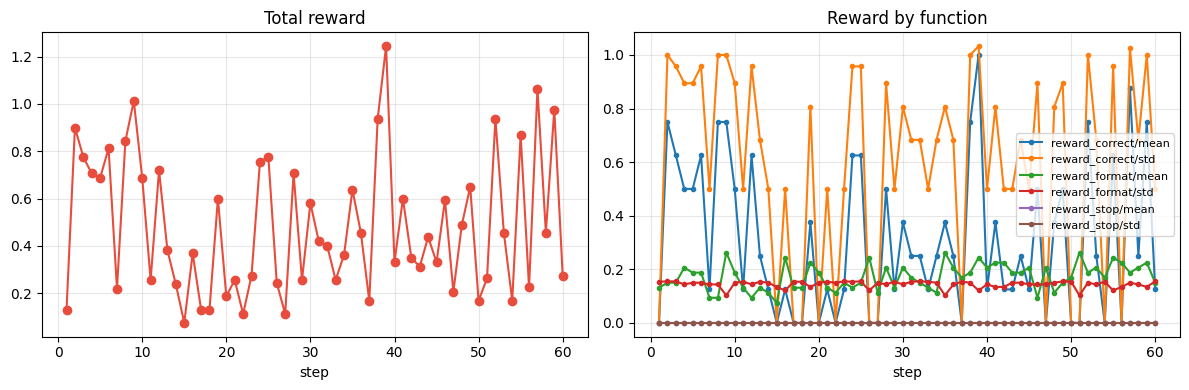


첫 5스텝 평균 보상: +0.640
끝 5스텝 평균 보상: +0.599


In [6]:
# ── 학습 곡선: 보상이 실제로 올랐는가 ────────────────────────────────
import pandas as pd, matplotlib.pyplot as plt

hist = [h for h in grpo_trainer.state.log_history if "reward" in h]
df = pd.DataFrame(hist)
cols = [c for c in df.columns if c.startswith("rewards/") or c == "reward"]
print(df[["step"] + cols].round(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df["step"], df["reward"], marker="o", color="#E74C3C")
ax[0].set_title("Total reward"); ax[0].set_xlabel("step"); ax[0].grid(alpha=.3)
for c in cols:
    if c != "reward":
        ax[1].plot(df["step"], df[c], marker=".", label=c.replace("rewards/", ""))
ax[1].set_title("Reward by function"); ax[1].set_xlabel("step")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"\n첫 5스텝 평균 보상: {df['reward'].head(5).mean():+.3f}")
print(f"끝 5스텝 평균 보상: {df['reward'].tail(5).mean():+.3f}")

In [7]:
# ── 학습 후 정답률 비교 ──────────────────────────────────────────────
trained = AutoModelForCausalLM.from_pretrained(
    "models/grpo-qwen2.5-0.5b", dtype=prof.torch_dtype, device_map="cuda")
acc_after = accuracy(trained, gsm_test)

print("=" * 46)
print(f"  학습 전 정답률 : {acc_before:.1%}")
print(f"  학습 후 정답률 : {acc_after:.1%}")
print(f"  변화           : {acc_after - acc_before:+.1%}")
print("=" * 46)
print("\n⚠️ 60스텝은 경향을 보기 위한 최소 설정이다. 0.5B 모델의 GSM8K 성능을")
print("   유의미하게 끌어올리려면 수천 스텝과 더 큰 모델이 필요하다.")
print("   여기서 확인할 것은 '보상 함수가 정책을 실제로 움직이는가' 이다.")

p3.free_gpu(trained)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:  78%|███████▊  | 227/290 [00:00<00:00, 2269.01it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2298.95it/s]

  학습 전 정답률 : 22.5%
  학습 후 정답률 : 30.0%
  변화           : +7.5%

⚠️ 60스텝은 경향을 보기 위한 최소 설정이다. 0.5B 모델의 GSM8K 성능을
   유의미하게 끌어올리려면 수천 스텝과 더 큰 모델이 필요하다.
   여기서 확인할 것은 '보상 함수가 정책을 실제로 움직이는가' 이다.
🧹 VRAM 사용: 5.56 GB


---
## 4️⃣ 결과 분석 및 DPO vs GRPO 비교

### GRPO 학습 결과 분석

위 실습에서 확인할 수 있는 핵심 포인트:

1. **보상 함수 기반 학습:** 별도의 선호 데이터 없이 규칙 기반 보상 함수만으로 학습 가능
2. **그룹 샘플링 효과:** 같은 질문에 대한 여러 응답을 비교하며 상대적으로 좋은 응답을 강화
3. **메모리 효율성:** Critic 네트워크 없이도 효과적인 RL 학습 수행

### ⚠️ 이 실습의 범위

**보여주는 것**
- 보상 모델 없이 **프로그램 채점만으로** 정책을 학습시킬 수 있다 (GRPO 의 핵심)
- 그룹 내 상대 비교로 어드밴티지를 만들기 때문에 **Critic 이 없다** — PPO 대비 로드 모델 1개 감소
- 보상 함수를 여러 개 조합하면 각각의 기여를 분리해 관찰할 수 있다

**보여주지 않는 것**
- 30스텝으로 0.5B 모델의 수학 실력이 크게 오르는 것. 정답률 변화는 노이즈 범위일 수 있다.
- DeepSeek-R1 급의 추론 능력 창발. 그것은 훨씬 큰 모델 · 훨씬 긴 학습의 결과다 (Session 05 참조).

### DPO vs GRPO: 언제 무엇을 선택할까?

**DPO를 선택하는 경우:**
- 고품질 선호 데이터가 이미 확보된 경우
- 주관적 판단이 필요한 태스크 (창의적 글쓰기, 대화 스타일 등)
- 빠르고 간단한 정렬이 필요한 경우

**GRPO를 선택하는 경우:**
- 정답이 명확한 태스크 (수학, 코딩 등)
- 규칙 기반 보상 함수를 설계할 수 있는 경우
- 모델의 추론 능력을 강화하고 싶은 경우
- 선호 데이터 수집이 어려운 경우

**실무적 조합:**
- DeepSeek-R1은 SFT → GRPO → Rejection Sampling → SFT → GRPO 순으로 반복 적용
- DPO와 GRPO를 순차적으로 적용하는 것도 가능 (예: DPO로 기본 정렬 후 GRPO로 추론 강화)

### 핵심 요약

| 핵심 개념 | 설명 |
|----------|------|
| **GRPO** | PPO에서 Critic을 제거하고, 그룹 내 상대적 보상으로 대체한 RL 알고리즘 |
| **Group Sampling** | 하나의 질문에 대해 여러 응답을 생성하여 비교하는 방식 |
| **Relative Advantage** | 그룹 내 보상의 평균/표준편차로 정규화한 상대적 이점 |
| **Critic-free** | Value function 네트워크 없이 RL 학습 → 메모리 효율적 |
| **Rule-based Reward** | 사람의 판단 없이 규칙으로 보상을 부여하는 방식 |
| **CoT 자연 발현** | GRPO 학습 중 모델이 스스로 사고 과정을 생성하기 시작하는 현상 |